In [1]:
# data: wine-class.csv

In [3]:
import pandas as pd
import matplotlib.pyplot
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('wine-class.csv')
df.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
df.shape

(178, 14)

In [9]:
df['class'].value_counts()

class
2    71
1    59
3    48
Name: count, dtype: int64

In [11]:
df.isnull().sum()

class                            0
alcohol                          0
 malic_acid                      0
 ash                             0
 alcalinity_of_ash               0
 magnesium                       0
 total_phenols                   0
 flavanoids                      0
 nonflavanoid_phenols            0
 proanthocyanins                 0
 color_intensity                 0
 hue                             0
 od280/od315_of_diluted_wines    0
 proline                         0
dtype: int64

In [13]:
# separate input and output

In [15]:
x = df.drop('class', axis = 1)
y = df['class']

#### cross validation

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   random_state= 0,
                                                   test_size= 0.20)

In [20]:
x_train.shape

(142, 13)

In [22]:
y_train.shape

(142,)

In [24]:
x_test.shape

(36, 13)

#### Build the model

In [27]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)

GaussianNB()

#### Evaluate

In [30]:
y_pred = gnb.predict(x_test)

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

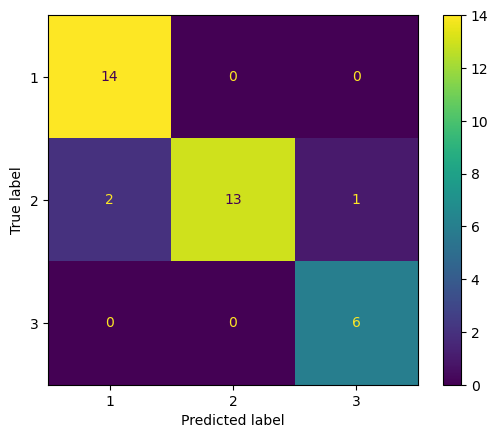

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.88      1.00      0.93        14
           2       1.00      0.81      0.90        16
           3       0.86      1.00      0.92         6

    accuracy                           0.92        36
   macro avg       0.91      0.94      0.92        36
weighted avg       0.93      0.92      0.92        36



In [42]:
accuracy_score(y_test, y_pred)

0.9166666666666666